In [ ]:
from torchvision import datasets as tv_datasets,transforms
import torch as torch
from torch.utils.data import Subset,DataLoader,WeightedRandomSampler
#make sure you run in colab: pip install lightning
from lightning.pytorch import LightningModule,Trainer,loggers


# Download the MNIST training dataset
mnist_dataset = tv_datasets.MNIST(
root="/",
train=True,
#do this to convert from PIL image format - includes rescaling to 0-1
transform=transforms.ToTensor(),
download=True
)

print(mnist_dataset.data.shape)

torch.Size([60000, 28, 28])


In [ ]:
#subsample the dataset into the desired class balance:
#– 3,500 images with the label 8
#– 1,200 images with the label 0
#– 300 images with the label 5

#how to subsample: shuffle the dataset so we can sample purely off encounters
generator = torch.Generator().manual_seed(42)
shuffled_indices = torch.randperm(len(mnist_dataset), generator=generator).tolist()
shuffled_dataset = Subset(mnist_dataset, shuffled_indices)

#define the label balance for the challenge dataset
label_quota = {8:3500,0:1200,5:300}
split_quota = {"train":3000,"val":1000,"test":1000}
#accumulate data structure. Do splits, and track indexes per label - allow for easy perf eval later
#change to random split assignment from by index - was exhausting smaller values in successive splits.
split_label_indices = {"train": {8:[],0:[],5:[]}, "val": {8:[],0:[],5:[]},"test": {8:[],0:[],5:[]}}
idx_used = 0
for idx, (_,label) in enumerate(shuffled_dataset):
  #do a 60 / 20 / 20 split
  if label in label_quota:
    #randomly assign split
    splits = list(split_quota.keys())
    split = splits[int(torch.randint(high=len(splits),size=(1,)))]
    split_label_indices[split][label].append(idx)
    label_quota[label]-=1
    split_quota[split]-=1
    if split_quota[split] == 0:
      del split_quota[split]
    if label_quota[label] == 0:
      del label_quota[label]
      if not label_quota:
        break

#check work:
for split, labels in split_label_indices.items():
    print(split, {
        label: len(indices)
        for label, indices in labels.items()
    })

def Custom_DS_MakeLoader(ds,split,label=None,batch_size = 64, shuffle = False):
    if label is None:
      subset = Subset(shuffled_dataset,[idx for list_ in ds[split].values() for idx in list_])
    else:
      subset =  Subset(shuffled_dataset, ds[split][label])

    loader = DataLoader(subset,batch_size=batch_size,shuffle=shuffle)

    return loader

#create a subset from the selected indeces
subsample_train_loader = Custom_DS_MakeLoader(split_label_indices,"train",shuffle=True) #want to shuffle each epoch
subsample_val_loader = Custom_DS_MakeLoader(split_label_indices,"val")
subsample_test_loader = Custom_DS_MakeLoader(split_label_indices,"test")


train {8: 2467, 0: 426, 5: 107}
val {8: 500, 0: 407, 5: 93}
test {8: 533, 0: 367, 5: 100}


In [ ]:
#now we have our training dataset, and evaluation dataset
#the model I'm going to choose will be a CNN with 3 convolutional / max pooling layers, flattening, dense / backpropogation, and output layer.
#will use adam optimizer.
#doesn't have to be CNN of course for MNIST, but will edge out non-CNN techniques so might as well.

#First, train a model without any special treatment of class imbalance, as this will be my performance baseline.
class DigitClassifier(LightningModule):

    def __init__(self):
        super().__init__()

        # Convolutional layers
        self.conv1 = torch.nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = torch.nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # Pooling (28-> 14-> 7)
        self.pool = torch.nn.MaxPool2d(kernel_size=2)

        # Fully connected layers
        self.fc1 = torch.nn.Linear(128 * 3 * 3, 128)
        self.fc2 = torch.nn.Linear(128, 10)

        # Loss
        self.loss_fn = torch.nn.CrossEntropyLoss()

    def forward(self, x):

        # Conv block 1
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool(x)

        # Conv block 2
        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool(x)

        # Conv block 3
        x = self.conv3(x)
        x = torch.relu(x)
        x = self.pool(x)

        # Flatten
        x = torch.flatten(x, start_dim=1)

        # Dense layers
        x = self.fc1(x)
        x = torch.relu(x)

        # Output logits
        x = self.fc2(x)

        return x

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

    def training_step(self, batch, batch_idx):
        x, y = batch

        logits = self(x)
        loss = self.loss_fn(logits, y)

        self.log(
            "train_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True
        )

        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch

        logits = self(x)
        loss = self.loss_fn(logits, y)

        predictions = torch.argmax(logits, dim=1)
        accuracy = (predictions == y).float().mean()

        self.log(
            "val_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True
        )

        self.log(
            "val_accuracy",
            accuracy,
            on_step=False,
            on_epoch=True,
            prog_bar=True
        )

        return loss

    def predict_step(self, batch, batch_idx):
        x, y = batch

        logits = self(x)

        return logits

#train the model

model = DigitClassifier()

logger = loggers.CSVLogger("logs", name="mnist")

trainer = Trainer(
    max_epochs=10,
    logger=logger,
    log_every_n_steps=15
)

trainer.fit(
    model,
    train_dataloaders=subsample_train_loader,
    val_dataloaders=subsample_val_loader
)

#after I obtain that, the special tweaks will be to address the class imbalance and see how much I can improve the model.
#the obvious first thing to try is weighting.
#I prefer overweighting smaller over underweighting larger, just to allow larger classes to retain larger variance
#so let's try that first.

#then try frame shift augmentation. Maybe do a mini ablation where I test the pairwise performance of the two methods.



INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv1   │ Conv2d           │    320 │ train │     0 │
│ 1 │ conv2   │ Conv2d           │ 18.5 K │ train │     0 │
│ 2 │ conv3   │ Conv2d           │ 73.9 K │ train │     0 │
│ 3 │ pool    │ MaxPool2d        │      0 │ train │     0 │
│ 4 │ fc1     │ Linear           │  147 K │ train │     0 │
│ 5 │ fc2     │ Linear           │  1.3 K │ train │     0 │
│ 6 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 241 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 241 K                                                                                                
Total estimated model params size (MB): 0.966                                                                      
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


In [ ]:
#see stats
#this isn't shhowing more than final epoch val. ugh. Keep trying to improve, but maybe just pivot into metrics
#also todo: make sure coding style (tabs , comment )
print(trainer.logged_metrics)

results = trainer.validate(
    model,
    dataloaders=subsample_val_loader
)

print(results)

#analyze per label
results = [result_ for result_ in [trainer.validate(model,dataloaders=Custom_DS_MakeLoader(split_label_indices,"val",label=i)) for i in (8,0,5)]]

print(results)

Output()

{'val_loss': tensor(0.0489), 'val_accuracy': tensor(0.9840), 'train_loss': tensor(0.0038)}


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │     0.984000027179718     │
│         val_loss          │    0.04890719801187515    │
└───────────────────────────┴───────────────────────────┘

Output()

[{'val_loss': 0.04890719801187515, 'val_accuracy': 0.984000027179718}]


...

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │    0.9925187230110168     │
│         val_loss          │   0.020071152597665787    │
└───────────────────────────┴───────────────────────────┘

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │    0.8865979313850403     │
│         val_loss          │    0.37524452805519104    │
└───────────────────────────┴───────────────────────────┘

[[{'val_loss': 0.008884354494512081, 'val_accuracy': 0.9960159659385681}], [{'val_loss': 0.020071152597665787, 'val_accuracy': 0.9925187230110168}], [{'val_loss': 0.37524452805519104, 'val_accuracy': 0.8865979313850403}]]


In [ ]:
#see stats per class (room for improvement)

#
#8 [[{'val_loss': 0.0005642921314574778, 'val_accuracy': 1.0}],
#0 [{'val_loss': 0.029056651517748833, 'val_accuracy': 0.9874686598777771}],
#5 [{'val_loss': 0.553814709186554, 'val_accuracy': 0.8823529481887817}]]

#big falloff on 5. So obvious room for improvement- we proceed.
#do mini-ablation. Look at different weighting, adding in frame shift augmentation, and each combination.

#first we'll try weighting with a sampler:

class_counts = {
    label: len(indices)
    for label, indices in split_label_indices["train"].items()
}

print(class_counts)

class_weights = {
    label: 1 / count
    for label, count in class_counts.items()
}

print(class_weights)

split_train_indices = [idx for list_ in split_label_indices["train"].values() for idx in list_]

#gives me weight for each index in dataset
sample_weights = [
    class_weights[shuffled_dataset[idx][1]]
    for idx in split_train_indices
]

print(sample_weights)
print(len(sample_weights))


custom_wr_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(split_train_indices),
    replacement=True)

#now make a custom data loader
subsample_train_loader_weighted = DataLoader(
    Subset(shuffled_dataset, split_train_indices),
    batch_size=64,
    sampler=custom_wr_sampler
)





{8: 2467, 0: 426, 5: 107}
{8: 0.00040535062829347385, 0: 0.002347417840375587, 5: 0.009345794392523364}
[0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040535062829347385, 0.00040

In [ ]:

#and train again.
trainer2 = Trainer(
    max_epochs=10,
    log_every_n_steps=15
)

trainer2.fit(
    model,
    train_dataloaders=subsample_train_loader_weighted,
    val_dataloaders=subsample_val_loader
)


In [ ]:
#eval again:
results = trainer2.validate(
    model,
    dataloaders=subsample_val_loader
)

print(results)

#analyze per label
results = [result_ for result_ in [trainer2.validate(model,dataloaders=Custom_DS_MakeLoader(split_label_indices,"val",label=i)) for i in (8,0,5)]]

print(results)


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │    0.9890000224113464     │
│         val_loss          │    0.05013671889901161    │
└───────────────────────────┴───────────────────────────┘

Output()

[{'val_loss': 0.05013671889901161, 'val_accuracy': 0.9890000224113464}]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │    0.9960159659385681     │
│         val_loss          │   0.017740700393915176    │
└───────────────────────────┴───────────────────────────┘

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │    0.9925187230110168     │
│         val_loss          │   0.029718462377786636    │
└───────────────────────────┴───────────────────────────┘

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │     0.938144326210022     │
│         val_loss          │    0.3022039234638214     │
└───────────────────────────┴───────────────────────────┘

[[{'val_loss': 0.017740700393915176, 'val_accuracy': 0.9960159659385681}], [{'val_loss': 0.029718462377786636, 'val_accuracy': 0.9925187230110168}], [{'val_loss': 0.3022039234638214, 'val_accuracy': 0.938144326210022}]]


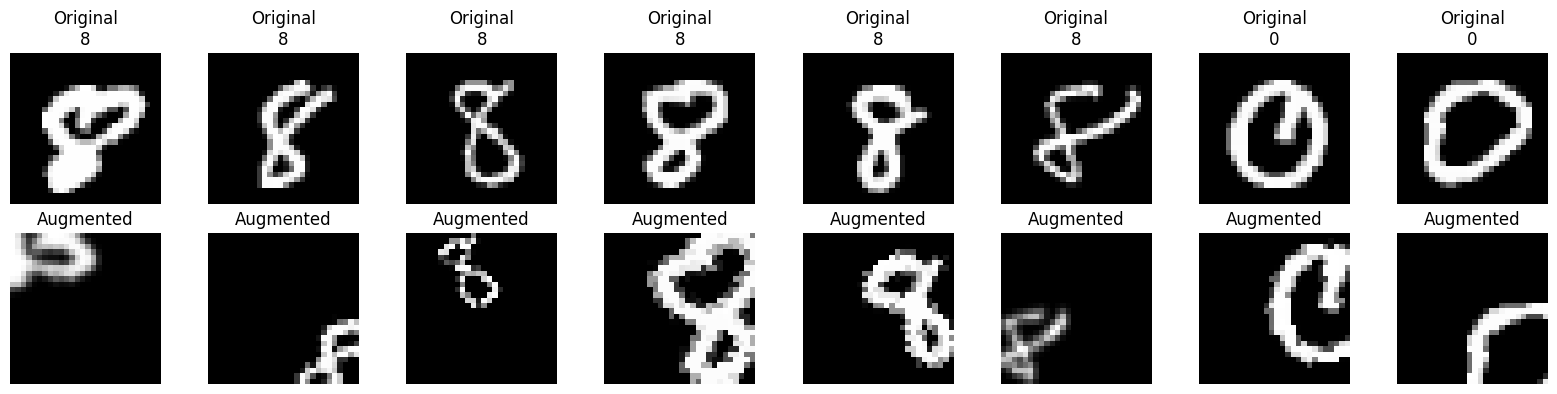

In [ ]:
#much better! .88 -> .96 (.93 2nd time)

#worth trying frame shift augmentation as well, and the combination.


#view it - ran this cell a few times, messed with parameters: tried to make as extreme as possible while
#still being consistently perceptible as the digit.

#I noticed that the degree variation, while sensible and seems to exist in the underlying dataset,
#introduced a new kind of grainyness. So, also decided to apply a blur

import matplotlib.pyplot as plt

class Custom_FrameShiftBlur_Augmentation(torch.nn.Module):
    def __init__(self,
                 translate=(0.4, 0.4),
                 degrees=45,
                 scale=(0.5,1.5),
                 blur_kernel=(3, 3),
                 #very minimal (so classifer doesn't overlearn blur only present in aug) to moderate
                 blur_sigma=(0.05, 0.65)):
        super().__init__()

        self.transform = transforms.Compose([
            transforms.RandomAffine(
                degrees=degrees,
                translate=translate,
                scale=scale
            ),
            transforms.GaussianBlur(
                kernel_size=blur_kernel,
                sigma=blur_sigma
            )
        ])


    def forward(self, x):
        return self.transform(x)

# Visualize it
x, y = next(iter(subsample_train_loader))

x_aug = torch.stack([
    Custom_FrameShiftBlur_Augmentation()(image)
    for image in x
])
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i in range(8):
    axes[0, i].imshow(x[i].squeeze(), cmap="gray")
    axes[0, i].set_title(f"Original\n{y[i].item()}")
    axes[0, i].axis("off")

    axes[1, i].imshow(x_aug[i].squeeze(), cmap="gray")
    axes[1, i].set_title("Augmented")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


In [ ]:

#make a variant of this - works on batched images. Previous was needed to work with

#last best: only translate (0.6, 0.6) and scale (0.5, 1.5),
class Custom_FrameShiftBlur_Augmentation_model(torch.nn.Module):
    def __init__(
        self,
        #bad: .25,.25
        translate=(0.6, 0.6),
        #degrees=45,
        #bad: .75,1.25
        scale=(0.5, 1.5),
        #translate=(0.4, 0.4),
        #degrees=45,
        #scale=(0.5, 1.5),
        #blur_kernel=(3, 3),
        #blur_sigma=(0.05, 0.65)
    ):
        super().__init__()

        self.transform = transforms.Compose([
            transforms.RandomAffine(
                degrees=0,
                translate=translate,
                scale=scale
            ),
            #transforms.GaussianBlur(
            #    kernel_size=blur_kernel,
            #    sigma=blur_sigma
            #)
        ])

    def forward(self, x):
        #return torch.stack([
        #    self.transform(image)
        #    for image in x
        #])
        return x


#redefine digit classifier with optional augmentation:

class DigitClassifier(LightningModule):

    def __init__(self, augment=False):
        super().__init__()

        # Optional training augmentation
        self.augmentation = (
          Custom_FrameShiftBlur_Augmentation_model()
          if augment else torch.nn.Identity()
        )

        # Convolutional layers
        self.conv1 = torch.nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = torch.nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # Pooling (28 -> 14 -> 7)
        self.pool = torch.nn.MaxPool2d(kernel_size=2)

        # Fully connected layers
        self.fc1 = torch.nn.Linear(128 * 3 * 3, 128)
        self.fc2 = torch.nn.Linear(128, 10)

        # Loss
        self.loss_fn = torch.nn.CrossEntropyLoss()

    def forward(self, x):

        # Conv block 1
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool(x)

        # Conv block 2
        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool(x)

        # Conv block 3
        x = self.conv3(x)
        x = torch.relu(x)
        x = self.pool(x)

        # Flatten
        x = torch.flatten(x, start_dim=1)

        # Dense layers
        x = self.fc1(x)
        x = torch.relu(x)

        # Output logits
        x = self.fc2(x)

        return x

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

    def training_step(self, batch, batch_idx):
        x, y = batch

        x = self.augmentation(x)

        logits = self(x)
        loss = self.loss_fn(logits, y)

        self.log(
            "train_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True
        )

        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch

        # NO augmentation during validation
        logits = self(x)
        loss = self.loss_fn(logits, y)

        predictions = torch.argmax(logits, dim=1)
        accuracy = (predictions == y).float().mean()

        self.log(
            "val_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True
        )

        self.log(
            "val_accuracy",
            accuracy,
            on_step=False,
            on_epoch=True,
            prog_bar=True
        )

        return loss

    def predict_step(self, batch, batch_idx):
        x, y = batch

        logits = self(x)

        return logits


  #train - compare to 1st stats:

model2 = DigitClassifier(augment=True)

logger2 = loggers.CSVLogger("logs2", name="mnist")

trainer3 = Trainer(
    max_epochs=15,
    logger=logger2,
    log_every_n_steps=15
)

trainer3.fit(
    model2,
    train_dataloaders=subsample_train_loader,
    val_dataloaders=subsample_val_loader
)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type                                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ augmentation │ Custom_FrameShiftBlur_Augmentation_model │      0 │ train │     0 │
│ 1 │ conv1        │ Conv2d                                   │    320 │ train │     0 │
│ 2 │ conv2        │ Conv2d                                   │ 18.5 K │ train │     0 │
│ 3 │ conv3        │ Conv2d                                   │ 73.9 K │ train │     0 │
│ 4 │ pool         │ MaxPool2d                                │      0 │ train │     0 │
│ 5 │ fc1          │ Linear                                   │  147 K │ train │     0 │
│ 6 │ fc2          │ Linear                                   │  1.3 K │ train │     0 │
│ 7 │ loss_fn      │ CrossEntropyLoss                         │      0 │ train │     0 │
└───┴──────────────┴──────────────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 241 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 241 K                                                                                                
Total estimated model params size (MB): 0.966                                                                      
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO: `Trainer.fit` stopped: `max_epochs=15` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


In [ ]:
#augmentation: performance notes. unscientific gues and check of various combinations and parameterizations.

#Found out after I did all these tests that I was using the wrong model in the trainer, so none of this applies. Also, for some reason, on rerunning everything, all of a sudden my 5 class is empty.

#1st attempt: used degree shift, blur, vertical and horizontal shift. verdict: poor.
#2nd attempt: removed blur, retained degree/vertical/horizontal shift. verdict: removing blur was much better, but didn't seem to improve over vanilla. (5 class acc .88)
#3nd attempt: increased epochs to let the augmentations 'cook' a bit more. This is where I'd love to know how to actually display the history more cleanly than I've figured out how to do with jupyter + the framework.
#val loss plateaus / creeps up after ~ epoch 9, doesn't seem to have helped hugely. Got class 5 acc. to .9
#4th attempt: go back to 10 epochs, remove degrees (noticed that had a grainy effect). class 5 acc = .9 (not bad), 2nd attempt, .84
#5th attempt: moderate other augmentations, keep degrees removed. Got worse? class 5 acc. = .79, 2nd attempt, .8
#noticing at this point there's some real variance, maybe need to run just a little longer (again, would be great to figure out how to actually show the history)
#increased epochs to 15. turned up the horizontal/vertical shift to add more variance (back to where I started: 5 class acc .88, 2nd trial .9,latest attempt was 5 class acc .95, so let's go foward with that.

print(trainer3.logged_metrics)

results = trainer3.validate(
    model2,
    dataloaders=subsample_val_loader
)

print(results)

#analyze per label
results = [result_ for result_ in [trainer3.validate(model2,dataloaders=Custom_DS_MakeLoader(split_label_indices,"val",label=i)) for i in (8,0,5)]]

print(results)

Output()

{'val_loss': tensor(0.0559), 'val_accuracy': tensor(0.9890), 'train_loss': tensor(0.0005)}


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │    0.9890000224113464     │
│         val_loss          │    0.05589524284005165    │
└───────────────────────────┴───────────────────────────┘

Output()

[{'val_loss': 0.05589524284005165, 'val_accuracy': 0.9890000224113464}]


...

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │    0.9877150058746338     │
│         val_loss          │    0.06473854184150696    │
└───────────────────────────┴───────────────────────────┘

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │    0.9462365508079529     │
│         val_loss          │     0.285139262676239     │
└───────────────────────────┴───────────────────────────┘

[[{'val_loss': 0.006057423539459705, 'val_accuracy': 0.9980000257492065}], [{'val_loss': 0.06473854184150696, 'val_accuracy': 0.9877150058746338}], [{'val_loss': 0.285139262676239, 'val_accuracy': 0.9462365508079529}]]


In [ ]:
#while it's not conclusive the augmentation really helps, going to try the combination of augmentation, longer epochs, + weighting and see how that does.

#Here I am really trying to increase specifically the undersampled class accuracy:
#vanilla: 0.88
#vanilla + weighting: .93 - .96
#augmented: .84 - .95
#augmented + weighting: .97


#and train again.
trainer4 = Trainer(
    max_epochs=15,
    log_every_n_steps=15
)

trainer4.fit(
    model2,
    train_dataloaders=subsample_train_loader_weighted,
    val_dataloaders=subsample_val_loader
)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type                                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ augmentation │ Custom_FrameShiftBlur_Augmentation_model │      0 │ train │     0 │
│ 1 │ conv1        │ Conv2d                                   │    320 │ train │     0 │
│ 2 │ conv2        │ Conv2d                                   │ 18.5 K │ train │     0 │
│ 3 │ conv3        │ Conv2d                                   │ 73.9 K │ train │     0 │
│ 4 │ pool         │ MaxPool2d                                │      0 │ train │     0 │
│ 5 │ fc1          │ Linear                                   │  147 K │ train │     0 │
│ 6 │ fc2          │ Linear                                   │  1.3 K │ train │     0 │
│ 7 │ loss_fn      │ CrossEntropyLoss                         │      0 │ train │     0 │
└───┴──────────────┴──────────────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 241 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 241 K                                                                                                
Total estimated model params size (MB): 0.966                                                                      
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: `Trainer.fit` stopped: `max_epochs=15` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


In [ ]:

print(trainer4.logged_metrics)

results = trainer4.validate(
    model2,
    dataloaders=subsample_val_loader
)

print(results)

#analyze per label
results = [result_ for result_ in [trainer4.validate(model2,dataloaders=Custom_DS_MakeLoader(split_label_indices,"val",label=i)) for i in (8,0,5)]]

print(results)

#first hit: .97 on class 5. Not bad! Do a few more trials to explore variance.
#.94, .92

#While this isn't super scientific (setting up hyperband etc seems like overkill for the challenge) - I'm resonably happy with the performance on the small class.
#maybe could have tried to decrease learning rate a bit and increased epochs to 20 to try to lower the variance I'm observing.

Output()

{'val_loss': tensor(0.0710), 'val_accuracy': tensor(0.9890), 'train_loss': tensor(3.7058e-06)}


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │    0.9890000224113464     │
│         val_loss          │    0.07104787230491638    │
└───────────────────────────┴───────────────────────────┘

Output()

[{'val_loss': 0.07104787230491638, 'val_accuracy': 0.9890000224113464}]


...

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │    0.9926289916038513     │
│         val_loss          │    0.08093752712011337    │
└───────────────────────────┴───────────────────────────┘

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │    0.9247311949729919     │
│         val_loss          │    0.2986781895160675     │
└───────────────────────────┴───────────────────────────┘

[[{'val_loss': 0.020658446475863457, 'val_accuracy': 0.9980000257492065}], [{'val_loss': 0.08093752712011337, 'val_accuracy': 0.9926289916038513}], [{'val_loss': 0.2986781895160675, 'val_accuracy': 0.9247311949729919}]]


In [ ]:
#Perform the test - use the combined weighting and augmentation.
results = trainer4.validate(
    model2,
    dataloaders=subsample_test_loader
)

print(results)

#analyze per label
results = [result_ for result_ in [trainer4.validate(model2,dataloaders=Custom_DS_MakeLoader(split_label_indices,"test",label=i)) for i in (8,0,5)]]

print(results)


Output()

/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │    0.9789999723434448     │
│         val_loss          │    0.15917286276817322    │
└───────────────────────────┴───────────────────────────┘

Output()

[{'val_loss': 0.15917286276817322, 'val_accuracy': 0.9789999723434448}]


...

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │    0.9836512207984924     │
│         val_loss          │    0.10482975095510483    │
└───────────────────────────┴───────────────────────────┘

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │    0.8700000047683716     │
│         val_loss          │    1.1130759716033936     │
└───────────────────────────┴───────────────────────────┘

[[{'val_loss': 0.017622441053390503, 'val_accuracy': 0.9962476491928101}], [{'val_loss': 0.10482975095510483, 'val_accuracy': 0.9836512207984924}], [{'val_loss': 1.1130759716033936, 'val_accuracy': 0.8700000047683716}]]


In [ ]:
#perform the test: only weighting.
#Perform the test - use the combined weighting and augmentation.
results = trainer4.validate(
    model,
    dataloaders=subsample_test_loader
)

print(results)

#analyze per label
results = [result_ for result_ in [trainer4.validate(model,dataloaders=Custom_DS_MakeLoader(split_label_indices,"test",label=i)) for i in (8,0,5)]]

print(results)

#given this one has lower variance and seems to generalize better (possibly, I overfit my val set while parameterizing augmentations) - just go with the weighting, and do not include augmentation.
#maybe could make augmentations an option, but lead with the most consistent on (just weighting)

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │    0.9879999756813049     │
│         val_loss          │    0.05351073294878006    │
└───────────────────────────┴───────────────────────────┘

Output()

[{'val_loss': 0.05351073294878006, 'val_accuracy': 0.9879999756813049}]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │     0.998123824596405     │
│         val_loss          │    0.00809620600193739    │
└───────────────────────────┴───────────────────────────┘

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │    0.9863760471343994     │
│         val_loss          │    0.05454632639884949    │
└───────────────────────────┴───────────────────────────┘

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val_accuracy        │    0.9399999976158142     │
│         val_loss          │    0.2917695939540863     │
└───────────────────────────┴───────────────────────────┘

[[{'val_loss': 0.00809620600193739, 'val_accuracy': 0.998123824596405}], [{'val_loss': 0.05454632639884949, 'val_accuracy': 0.9863760471343994}], [{'val_loss': 0.2917695939540863, 'val_accuracy': 0.9399999976158142}]]
